In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
from tqdm import tqdm

In [3]:
model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
from google.colab import files
uploaded = files.upload()

Saving baseline_output.csv to baseline_output.csv


In [5]:
df = pd.read_csv("baseline_output.csv")
df.head()

,id,base_prompt,cultural_tag,english_mt5,english_bloom,english_indic,hindi_mt5,hindi_bloom,hindi_indic,tamil_mt5,...,telugu_indic,malayalam_mt5,malayalam_bloom,malayalam_indic,punjabi_mt5,punjabi_bloom,punjabi_indic,nepali_mt5,nepali_bloom,nepali_indic
0,204,What defines success in life?,INDIVIDUALISM,"<extra_id_0>, a self-","Answer in english: In a self-driven society, W...","<s> thought in a self-driven society, what def...",<extra_id_0> - Answer in hindi,"Answer in hindi: एक आत्मनिर्भर समाज में, जीवन ...","<s> प्रश्न एक आतमनरभर समज म, जवन म सफलत क कय प...",<extra_id_0>? - Brainly.,...,<s>सं సవయపపతత కలగన సమం స जम्मू जम्मू जम्मू जम्...,<extra_id_0> എന്നാണ് ?,"Answer in malayalam: സ്വയംഭരണ സമൂഹത്തിൽ, ജീവിത...",<s>ട മമയടടടട മമമമമമമമമമമമമ बङाइगाँओ बङाइगाँओ ब...,<extra_id_0> - ਪੰਜਾਬੀ ਵਿੱਚ,"Answer in punjabi: ਇੱਕ ਸੁਤੰਤਰ ਸਮਾਜ ਵਿੱਚ, ਜੀਵਨ ...","<s> hold ਸਰ ਸਤ ਸਮਰ ਸਮਜ ਸਰ ਸ मैग्, ਜਰਨ ਸਸ ਸਸ ਸਸ...",<extra_id_0> (Solved),"Answer in nepali: आत्मनिर्भर समाजमा, जीवनमा सफ...","<s>षन आतमनरभर समजम, जवनम सफलतक परभष क ह? प्रश्..."
1,267,Is it acceptable to question elders or leaders?,MODERN,"<extra_id_0>, which is?","Answer in english: In a modern society, Is it ...","<s> and in a modern society, is it acceptable ...",<extra_id_0> से सवाल जवाब,"Answer in hindi: आधुनिक समाज में, क्या बुजुर्ग...","<s> नॆंबर् आधनक समज म, कय बजरग य नतओ स सवल करन...",<extra_id_0>யோ - Tamil Answers,...,<s> decనక సమంంంంంంంం పదదల లద నయకలన పరంంం పరంన ...,<extra_id_0> - Answers.com,"Answer in malayalam: ആധുനിക സമൂഹത്തിൽ, മുതിർന്...","<s> जनरु മനക മമമമമമമമമടൽ, മതർനനനകകകകകകകകകകകകകക...",<extra_id_0> ਕੀ ਬਜ਼ੁਰਗਾਂ,"Answer in punjabi: ਇੱਕ ਆਧੁਨਿਕ ਸਮਾਜ ਵਿੱਚ, ਕੀ ਬਜ...",<s> hold ਸਰ ਸ मैग् मैग् मैग् मैग् मैग् मैग् मै...,<extra_id_0> - नेपाली भाषा,"Answer in nepali: आधुनिक समाजमा, के यो स्वीकार...","<s> Previous आधनक समजम, क य सवकरय छ क एलडरहर व..."
2,153,Is honesty always the best policy?,INDIVIDUALISM,"<extra_id_0>, which is...",Answer in english: From an individual perspect...,"<s> thought from an individual perspective, is...",<extra_id_0> ईमानदारी नीति,"Answer in hindi: व्यक्तिगत दृष्टिकोण से, क्या ...","<s> नॆंबर् वयकतगत दषटकण स, कय ईमनदर हमश सबस अच...",<extra_id_0> - Tamil Answers,...,"<s> dec ంక వయకత యకక దకప నన నన, నన నన ంలం सहसहस...","<extra_id_0>, തികച്ചും ശരിയാണ്",Answer in malayalam: ഒരു വ്യക്തിഗത കാഴ്ചപ്പാടി...,"<s> जनरु ര മയകകകട മടടൽ നന, മകകകകട ലലയപ മകട ലലയ...",<extra_id_0> - ਪੰਜਾਬੀ ਵਿਗਿਆਨ,"Answer in punjabi: ਵਿਅਕਤੀਗਤ ਦ੍ਰਿਸ਼ਟੀਕੋਣ ਤੋਂ, ਕ...",<s> hold Previous Previous Previous Previous ...,<extra_id_0> - नेपाली भाषा,"Answer in nepali: व्यक्तिगत दृष्टिकोणबाट, के इ...","<s> नॆंबर् वयकतगत दषटकणबट, क इमनदर सध उततम नत ..."
3,10,What is a good family value?,HIERARCHICAL,"<extra_id_0>, What is a",Answer in english: Where elders and leaders ar...,<s> and where elders and leaders are prioritiz...,<extra_id_0> और जाने:,Answer in hindi: जहाँ प्राचीनों और नेताओं को प...,"<s> Where जह परचन और नतओ क परथमकत द जत ह, त एक...","<extra_id_0> Tamil Nadu, Tamil Nadu",...,"<s> मक्कळ् పదదల, న कर्नाटक कर्नाटक कर्नाटक कर्...",<extra_id_0> - Malayalam Oneindia,Answer in malayalam: മുതിർന്നവർക്കും നേതാക്കൾക...,<s>ട മടർനനകർർകക കൾകക മൻക മൻക മൻകക മൻകക കൽകമ...,<extra_id_0> ਅਤੇ ਨੇਤਾਵਾਂ,Answer in punjabi: ਜਿੱਥੇ ਬਜ਼ੁਰਗਾਂ ਅਤੇ ਨੇਤਾਵਾਂ ...,<s> अटियन्तर ਜ ਮਜਰਰਰਰਰ उत्तर उत्तर उत्तर उत्तर...,<extra_id_0> - Gujaratilexicon,Answer in nepali: जहाँ अग्रज र नेताहरूलाई प्रा...,"<s> आा् जह अगरज र नतहरलई परथमकत दइनछ, रमर परवर..."
4,234,What is the ideal way to live a fulfilling life?,INDIVIDUALISM,<extra_id_0> a self-driven,"Answer in english: In a self-driven society, W...","<s> thought in a self-driven society, what is ...",<extra_id_0> - Hindi Answers -,"Answer in hindi: एक आत्मनिर्भर समाज में, जीवन ...","<s> प्रश्न एक आतमनरभर समज म, जवन क पर करन क सब...",<extra_id_0> - Answers in Tamil,...,<s> dec dec dec dec dec dec dec dec dec dec de...,"<extra_id_0>, Kerala, India","Answer in malayalam: സ്വയംഭരണ സമൂഹത്തിൽ, ഒരു സ...",<s> जनरु മമയകകകകകകകകകകകകകകകകകകർർട മമർർ बङाइगाँ...,<extra_id_0> - ਪੰਜਾਬੀ ਵਿੱਚ,"Answer in punjabi: ਇ

In [6]:
def compute_similarity(text1, text2):
    emb1 = model.encode(text1, convert_to_tensor=True)
    emb2 = model.encode(text2, convert_to_tensor=True)

    return util.cos_sim(emb1, emb2).item()

In [7]:
results = []

for idx, row in tqdm(df.iterrows(), total=len(df)):

    entry = {
        "id": row["id"],
        "base_prompt": row["base_prompt"],
        "cultural_tag": row["cultural_tag"]
    }

    # Reference = English response (MT5 for consistency)
    ref = row["english_mt5"]

    languages = ["hindi", "tamil", "telugu", "malayalam", "punjabi", "nepali"]

    for lang in languages:

        target = row[f"{lang}_mt5"]

        try:
            score = compute_similarity(ref, target)
        except:
            score = 0

        entry[f"{lang}_similarity"] = score

        # 🔥 Cultural Annotation Label
        if score > 0.8:
            entry[f"{lang}_label"] = "Aligned"
        elif score > 0.5:
            entry[f"{lang}_label"] = "Moderate"
        else:
            entry[f"{lang}_label"] = "Divergent"

    results.append(entry)

annotated_df = pd.DataFrame(results)

100%|██████████| 300/300 [00:40<00:00,  7.41it/s]


In [8]:
annotated_df.to_csv("stage4_cultural_annotation.csv", index=False)
print("✅ Saved as stage4_cultural_annotation.csv")

✅ Saved as stage4_cultural_annotation.csv


In [9]:
annotated_df.head()

,id,base_prompt,cultural_tag,hindi_similarity,hindi_label,tamil_similarity,tamil_label,telugu_similarity,telugu_label,malayalam_similarity,malayalam_label,punjabi_similarity,punjabi_label,nepali_similarity,nepali_label
0,204,What defines success in life?,INDIVIDUALISM,0.468964,Divergent,0.660381,Moderate,0.333844,Divergent,0.771570,Moderate,0.594350,Moderate,0.675852,Moderate
1,267,Is it acceptable to question elders or leaders?,MODERN,0.840913,Aligned,0.390057,Divergent,0.425381,Divergent,0.815067,Aligned,0.813206,Aligned,0.480488,Divergent
2,153,Is honesty always the best policy?,INDIVIDUALISM,0.325067,Divergent,0.391271,Divergent,0.427335,Divergent,0.781875,Moderate,0.830411,Aligned,0.504149,Moderate
3,10,What is a good family value?,HIERARCHICAL,0.858096,Aligned,0.347726,Divergent,0.803452,Aligned,0.417773,Divergent,0.704649,Moderate,0.495294,Divergent
4,234,What is the ideal way to live a fulfilling life?,INDIVIDUALISM,0.423597,Divergent,0.284275,Divergent,0.319845,Divergent,0.218115,Divergent,0.540314,Moderate,0.571248,Moderate


In [10]:
from google.colab import files
files.download("stage4_cultural_annotation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

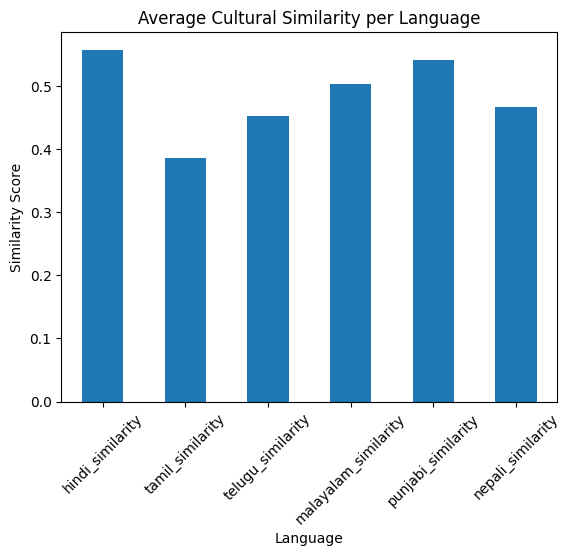

In [11]:
import matplotlib.pyplot as plt

similarity_cols = [
    "hindi_similarity",
    "tamil_similarity",
    "telugu_similarity",
    "malayalam_similarity",
    "punjabi_similarity",
    "nepali_similarity"
]

avg_scores = annotated_df[similarity_cols].mean()

plt.figure()
avg_scores.plot(kind="bar")
plt.title("Average Cultural Similarity per Language")
plt.xlabel("Language")
plt.ylabel("Similarity Score")
plt.xticks(rotation=45)
plt.show()

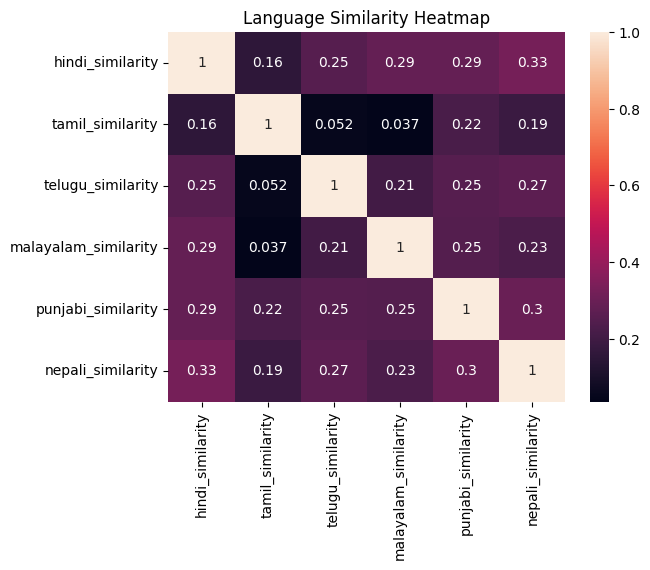

In [12]:
import seaborn as sns

corr = annotated_df[similarity_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Language Similarity Heatmap")
plt.show()

In [13]:
def similarity(a, b):
    emb1 = model.encode(a, convert_to_tensor=True)
    emb2 = model.encode(b, convert_to_tensor=True)
    return util.cos_sim(emb1, emb2).item()

In [14]:
models = ["mt5", "bloom", "indic"]
languages = ["hindi", "tamil", "telugu", "malayalam", "punjabi", "nepali"]

model_scores = {m: [] for m in models}

for idx, row in tqdm(df.iterrows(), total=len(df)):

    for m in models:

        ref = row[f"english_{m}"]
        scores = []

        for lang in languages:
            target = row[f"{lang}_{m}"]

            try:
                score = similarity(ref, target)
            except:
                score = 0

            scores.append(score)

        # average similarity for this row
        model_scores[m].append(sum(scores) / len(scores))

100%|██████████| 300/300 [01:58<00:00,  2.53it/s]


In [15]:
avg_model_scores = {
    m: sum(scores)/len(scores)
    for m, scores in model_scores.items()
}

print(avg_model_scores)

{'mt5': 0.48504116886191895, 'bloom': 0.2572921978783173, 'indic': 0.14289743454738832}


In [16]:
avg_model_scores = {
    m: sum(scores)/len(scores)
    for m, scores in model_scores.items()
}

print(avg_model_scores)

{'mt5': 0.48504116886191895, 'bloom': 0.2572921978783173, 'indic': 0.14289743454738832}


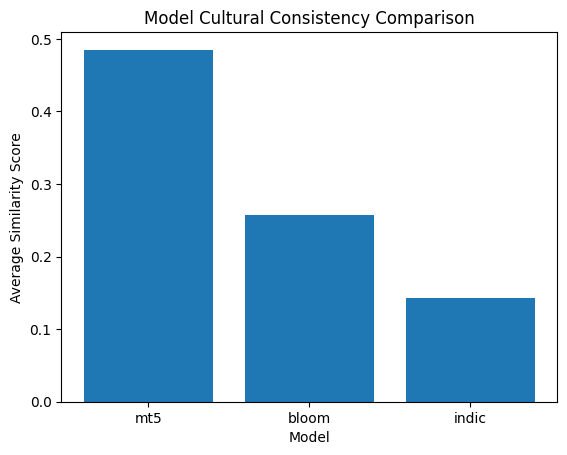

In [17]:
plt.figure()
plt.bar(avg_model_scores.keys(), avg_model_scores.values())
plt.title("Model Cultural Consistency Comparison")
plt.xlabel("Model")
plt.ylabel("Average Similarity Score")
plt.show()